# Notebook 15 — Hybrid Models (Local): Soft Voting Ensemble & Feature Fusion MLP

**Project:** MSc AI Dissertation — AI-Generated Text Detection  
**Student:** Abdul Hannaan Mohammed | B00409227 | UWS  
**Supervisor:** Dr Tahir Mahmood  

## What this notebook produces
1. **Hybrid 3** — Soft-Voting Ensemble of RoBERTa + BERT + DistilBERT (no training needed)  
2. **Hybrid 4** — Multi-Feature Fusion MLP: RoBERTa prob + TF-IDF + statistical features  
3. **McNemar's statistical test** comparing best hybrid vs best individual model (supervisor feedback point 12)  
4. **Full comparison figures** — all 9 models (5 original + 4 hybrid)  
5. **Combined master results CSV** — all 9 models across all 5 conditions  

## Academic References (Harvard)
- **Soft voting / Deep Ensembles:** Lakshminarayanan, B. et al. (2017) 'Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles', *NeurIPS*. arXiv:1612.01474  
- **Feature fusion / Ghostbuster:** Verma, S. et al. (2023) 'Ghostbuster: Detecting ChatGPT-Generated Academic Writing'. arXiv:2305.15047  
- **McNemar's test:** Dietterich, T.G. (1998) 'Approximate Statistical Tests for Comparing Supervised Classification Learning Algorithms', *Neural Computation*, 10(7), pp. 1895–1923. doi:10.1162/089976698300017197  

## Run this notebook AFTER
- Notebook 10 (all 5 original models evaluated)
- Notebook 14 (H1 + H2 results downloaded from Colab to `results/metrics/hybrid_nb14_results.csv`)

## Expected runtime: ~30–60 minutes on local machine (no GPU needed for H3 + H4)

In [7]:
# ── Cell 1: Imports and paths ─────────────────────────────────────────────────
import os
import json
import pickle
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, classification_report
)
from scipy.stats import chi2

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

NOTEBOOK_DIR    = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT    = os.path.dirname(NOTEBOOK_DIR)
DATA_PROCESSED  = os.path.join(PROJECT_ROOT, 'data', 'processed')
DATA_ADV        = os.path.join(PROJECT_ROOT, 'data', 'adversarial')
DATA_M4         = os.path.join(PROJECT_ROOT, 'data', 'raw', 'm4')
CHECKPOINTS_DIR = os.path.join(PROJECT_ROOT, 'models', 'checkpoints')
MODELS_DIR      = os.path.join(PROJECT_ROOT, 'models')
RESULTS_METRICS = os.path.join(PROJECT_ROOT, 'results', 'metrics')
RESULTS_FIGS    = os.path.join(PROJECT_ROOT, 'results', 'figures')

for p in [RESULTS_METRICS, RESULTS_FIGS]:
    os.makedirs(p, exist_ok=True)

MAX_LENGTH = 512
BATCH_SIZE = 16

print('Paths configured.')
print(f'Project root: {PROJECT_ROOT}')

Device: cuda
Paths configured.
Project root: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection


In [8]:
# ── Cell 2: Dataset registry (same as Notebook 10) ────────────────────────────
DATASETS = {
    'HC3-Clean'     : {'path': os.path.join(DATA_PROCESSED, 'test.csv'),                           'text_col': 'text',           'condition': 'balanced'},
    'Pegasus-Attack': {'path': os.path.join(DATA_ADV, 'pegasus_rewritten_500.csv'),               'text_col': 'rewritten_text', 'condition': 'ai_only'},
    'QuillBot-Attack': {'path': os.path.join(DATA_ADV, 'quillbot', 'quillbot_samples.csv'),       'text_col': 'rewritten_text', 'condition': 'ai_only'},
    'ChatGPT-Attack': {'path': os.path.join(DATA_ADV, 'chatgpt', 'chatgpt_samples.csv'),          'text_col': 'rewritten_text', 'condition': 'ai_only'},
    'Cross-Dataset' : {'path': os.path.join(DATA_M4, 'cross_dataset_test.csv'),                   'text_col': 'text',           'condition': 'balanced'},
}

print('Dataset availability:')
for name, info in DATASETS.items():
    status = '✅ Found' if os.path.exists(info['path']) else '❌ Missing'
    print(f'  {name:20s}: {status}')

Dataset availability:
  HC3-Clean           : ✅ Found
  Pegasus-Attack      : ✅ Found
  QuillBot-Attack     : ✅ Found
  ChatGPT-Attack      : ✅ Found
  Cross-Dataset       : ✅ Found


In [9]:
# ── Cell 3: Transformer inference utilities ───────────────────────────────────
class InferenceDataset(Dataset):
    def __init__(self, texts, tokenizer):
        self.encodings = tokenizer(
            texts, max_length=MAX_LENGTH,
            padding='max_length', truncation=True
        )
    def __len__(self):
        return len(self.encodings['input_ids'])
    def __getitem__(self, idx):
        return {k: torch.tensor(v[idx], dtype=torch.long)
                for k, v in self.encodings.items()}


def get_transformer_probs(texts, model_path, batch_size=BATCH_SIZE):
    """
    Run a HuggingFace transformer model and return softmax probabilities
    for the AI class (index 1). Returns numpy array of shape (n_samples,).
    """
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model     = AutoModelForSequenceClassification.from_pretrained(model_path)
    model     = model.to(DEVICE)
    model.eval()

    dataset = InferenceDataset(texts, tokenizer)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_probs = []
    with torch.no_grad():
        for batch in loader:
            inputs = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**inputs).logits
            probs  = torch.softmax(logits, dim=-1)[:, 1]
            all_probs.extend(probs.cpu().numpy())

    del model
    torch.cuda.empty_cache()
    return np.array(all_probs)


def compute_metrics(true_labels, preds, probs, condition):
    """Compute metrics compatible with all_results.csv from Notebook 10."""
    if condition == 'ai_only':
        detection_rate = sum(p == 1 for p in preds) / len(preds)
        return {
            'accuracy': None, 'precision': None,
            'recall': round(detection_rate, 4), 'f1': None,
            'roc_auc': None, 'attack_success': round(1 - detection_rate, 4)
        }
    else:
        acc = accuracy_score(true_labels, preds)
        p, r, f1, _ = precision_recall_fscore_support(
            true_labels, preds, average='binary', pos_label=1, zero_division=0
        )
        try:
            auc = roc_auc_score(true_labels, probs)
        except Exception:
            auc = None
        return {
            'accuracy': round(acc, 4), 'precision': round(p, 4),
            'recall': round(r, 4), 'f1': round(f1, 4),
            'roc_auc': round(auc, 4) if auc else None,
            'attack_success': None
        }

print('Inference utilities defined.')

Inference utilities defined.


## 1. Hybrid 3 — Soft-Voting Ensemble (RoBERTa + BERT + DistilBERT)

### Architecture
```
Text Input
  ↓
RoBERTa-hc3-best  →  P(AI)_roberta
BERT-hc3-best     →  P(AI)_bert
DistilBERT-hc3    →  P(AI)_distilbert
  ↓
P(AI)_ensemble = (P_roberta + P_bert + P_distilbert) / 3
  ↓
If P(AI)_ensemble ≥ 0.5 → AI | else → Human
```

### Why better than individual transformers?
Ensemble theory (Lakshminarayanan et al., 2017) demonstrates that combining
diverse classifiers reduces prediction variance. Your three models fail at *different*
rates under attacks: DistilBERT has 19% QuillBot ASR while RoBERTa has 13.4%.
An adversarial attack must fool ALL three simultaneously to succeed.

### Reference
- Lakshminarayanan, B. et al. (2017) 'Simple and Scalable Predictive Uncertainty
  Estimation using Deep Ensembles', *NeurIPS*. arXiv:1612.01474

## 2. Hybrid 4 — Multi-Feature Fusion MLP

### Architecture
```
Text
  ↓
[Signal 1] RoBERTa-hc3-best  →  P(AI): 1 feature
[Signal 2] TF-IDF             →  500 features (top vocabulary features)
[Signal 3] Statistical        →  6 features:
                                   text_length, avg_word_length,
                                   type_token_ratio, punct_density,
                                   avg_sentence_length, lexical_richness
  ↓ Concatenate: 507 features total
MLP: Linear(507→256) → ReLU → Dropout(0.3)
   → Linear(256→64)  → ReLU → Dropout(0.2)
   → Linear(64→2)    → Softmax
  ↓
{Human, AI}
```

### Why better than individual models?
Each signal captures a *different* aspect of text. ChatGPT rewrites change
semantics but vocabulary distributions and statistical patterns remain distinct.
An attack that defeats the semantic (RoBERTa) signal may not defeat the
statistical (TF-IDF/perplexity) signal. This is the multi-signal fusion principle
used by Ghostbuster (Verma et al., 2023).

### Reference
- Verma, S. et al. (2023) 'Ghostbuster: Detecting ChatGPT-Generated Academic Writing'.
  arXiv:2305.15047
- Mitrovic, J. et al. (2023) 'ChatGPT or Human? Detect and Explain'. arXiv:2301.13852

In [11]:
# ── Cell 7: H4 — Feature extraction utilities ─────────────────────────────────
import re
import string

def extract_statistical_features(texts):
    """
    Extract 6 stylometric features per text.
    These are orthogonal to neural semantic features and capture
    surface-level writing patterns (Verma et al., 2023).

    Features:
      1. text_length         — total word count
      2. avg_word_length     — average word length in characters
      3. type_token_ratio    — vocabulary richness (unique words / total words)
      4. punct_density       — punctuation marks per 100 words
      5. avg_sentence_len    — average sentence length in words
      6. lexical_richness    — proportion of words appearing only once
    """
    features = []
    for text in texts:
        words     = text.split()
        n_words   = max(len(words), 1)
        sentences = re.split(r'[.!?]+', text.strip())
        sentences = [s for s in sentences if s.strip()]
        n_sents   = max(len(sentences), 1)

        # Feature 1: text length
        f1 = n_words

        # Feature 2: avg word length
        word_lens = [len(w.strip(string.punctuation)) for w in words if w.strip(string.punctuation)]
        f2 = np.mean(word_lens) if word_lens else 0

        # Feature 3: type-token ratio
        f3 = len(set(w.lower() for w in words)) / n_words

        # Feature 4: punctuation density (per 100 words)
        n_punct = sum(1 for c in text if c in string.punctuation)
        f4 = (n_punct / n_words) * 100

        # Feature 5: average sentence length
        f5 = n_words / n_sents

        # Feature 6: lexical richness (hapax legomena ratio)
        from collections import Counter
        word_counts = Counter(w.lower() for w in words)
        f6 = sum(1 for v in word_counts.values() if v == 1) / n_words

        features.append([f1, f2, f3, f4, f5, f6])

    return np.array(features, dtype=np.float32)


print('Statistical feature extractor defined. Features:')
print('  1. text_length       — total word count')
print('  2. avg_word_length   — average word length')
print('  3. type_token_ratio  — vocabulary richness')
print('  4. punct_density     — punctuation per 100 words')
print('  5. avg_sentence_len  — words per sentence')
print('  6. lexical_richness  — hapax legomena ratio')

Statistical feature extractor defined. Features:
  1. text_length       — total word count
  2. avg_word_length   — average word length
  3. type_token_ratio  — vocabulary richness
  4. punct_density     — punctuation per 100 words
  5. avg_sentence_len  — words per sentence
  6. lexical_richness  — hapax legomena ratio


In [12]:
# ── Cell 8: H4 — Build feature matrix for training ────────────────────────────
ROBERTA_PATH = os.path.join(CHECKPOINTS_DIR, 'roberta-hc3-best')
TFIDF_MAX_FEATURES = 500

# Load training and validation data
train_df = pd.read_csv(os.path.join(DATA_PROCESSED, 'train.csv'))
val_df   = pd.read_csv(os.path.join(DATA_PROCESSED, 'val.csv'))

train_texts  = train_df['text'].astype(str).tolist()
train_labels = train_df['label'].tolist()
val_texts    = val_df['text'].astype(str).tolist()
val_labels   = val_df['label'].tolist()

print('--- Feature 1: RoBERTa probability ---')
if os.path.isdir(ROBERTA_PATH):
    print('Extracting RoBERTa probabilities for training set (~10-15 min)...')
    train_roberta_probs = get_transformer_probs(train_texts, ROBERTA_PATH)
    val_roberta_probs   = get_transformer_probs(val_texts,   ROBERTA_PATH)
    print(f'  Train: {train_roberta_probs.shape} | Val: {val_roberta_probs.shape}')
else:
    print('WARNING: RoBERTa checkpoint not found. Using random probs for demo.')
    train_roberta_probs = np.random.rand(len(train_texts)).astype(np.float32)
    val_roberta_probs   = np.random.rand(len(val_texts)).astype(np.float32)

print('\n--- Feature 2: TF-IDF (500 features) ---')
tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),   # unigrams and bigrams
    min_df=5,             # ignore rare terms
    strip_accents='unicode',
    sublinear_tf=True     # apply log(1+tf) for better scaling
)
train_tfidf = tfidf.fit_transform(train_texts).toarray().astype(np.float32)
val_tfidf   = tfidf.transform(val_texts).toarray().astype(np.float32)
print(f'  Train: {train_tfidf.shape} | Val: {val_tfidf.shape}')

# Save TF-IDF vectorizer for inference
tfidf_path = os.path.join(MODELS_DIR, 'logistic_regression', 'h4_tfidf.pkl')
os.makedirs(os.path.dirname(tfidf_path), exist_ok=True)
with open(tfidf_path, 'wb') as f:
    pickle.dump(tfidf, f)
print(f'  TF-IDF vectorizer saved: {tfidf_path}')

print('\n--- Feature 3: Statistical features (6 per sample) ---')
train_stats = extract_statistical_features(train_texts)
val_stats   = extract_statistical_features(val_texts)
print(f'  Train: {train_stats.shape} | Val: {val_stats.shape}')

# Normalise statistical features to [0, 1] range
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_stats = scaler.fit_transform(train_stats)
val_stats   = scaler.transform(val_stats)
scaler_path = os.path.join(MODELS_DIR, 'logistic_regression', 'h4_scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'  Scaler saved: {scaler_path}')

# Concatenate all features: [roberta_prob (1) | tfidf (500) | stats (6)] = 507
train_X = np.concatenate([
    train_roberta_probs.reshape(-1, 1),
    train_tfidf,
    train_stats
], axis=1).astype(np.float32)

val_X = np.concatenate([
    val_roberta_probs.reshape(-1, 1),
    val_tfidf,
    val_stats
], axis=1).astype(np.float32)

print(f'\nFull feature matrix: {train_X.shape} (samples x features)')
print(f'  RoBERTa prob: 1 | TF-IDF: {TFIDF_MAX_FEATURES} | Statistical: 6 = {1 + TFIDF_MAX_FEATURES + 6} total')

--- Feature 1: RoBERTa probability ---
Extracting RoBERTa probabilities for training set (~10-15 min)...
  Train: (55156,) | Val: (11819,)

--- Feature 2: TF-IDF (500 features) ---
  Train: (55156, 500) | Val: (11819, 500)
  TF-IDF vectorizer saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\models\logistic_regression\h4_tfidf.pkl

--- Feature 3: Statistical features (6 per sample) ---
  Train: (55156, 6) | Val: (11819, 6)
  Scaler saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\models\logistic_regression\h4_scaler.pkl

Full feature matrix: (55156, 507) (samples x features)
  RoBERTa prob: 1 | TF-IDF: 500 | Statistical: 6 = 507 total


In [13]:
# ── Cell 9: H4 — MLP architecture and training ────────────────────────────────
class FeatureFusionMLP(nn.Module):
    """
    Hybrid 4: Multi-Feature Fusion MLP.

    Combines three orthogonal detection signals:
      1. RoBERTa probability  — semantic/contextual signal
      2. TF-IDF features      — vocabulary distribution signal
      3. Statistical features — stylometric/surface signal

    This approach is motivated by Verma et al. (2023) Ghostbuster:
    multi-signal fusion improves robustness because different attacks
    defeat different signals but rarely all simultaneously.

    Reference:
      Verma, S. et al. (2023) arXiv:2305.15047
    """
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)


class FusionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


INPUT_DIM = train_X.shape[1]
h4_model  = FeatureFusionMLP(INPUT_DIM).to(DEVICE)

trainable_h4 = sum(p.numel() for p in h4_model.parameters())
print(f'H4 MLP — input dim: {INPUT_DIM} | parameters: {trainable_h4:,}')

# DataLoaders
train_loader = DataLoader(
    FusionDataset(train_X, train_labels),
    batch_size=128, shuffle=True
)
val_loader = DataLoader(
    FusionDataset(val_X, val_labels),
    batch_size=128, shuffle=False
)

# Training with class weights for imbalance
class_counts = np.bincount(train_labels)
class_w      = torch.tensor(1.0 / class_counts / (1.0/class_counts).sum() * 2,
                              dtype=torch.float).to(DEVICE)
criterion    = nn.CrossEntropyLoss(weight=class_w)
optimizer    = Adam(h4_model.parameters(), lr=1e-3, weight_decay=1e-4)

H4_EPOCHS     = 50
H4_CKPT_PATH  = os.path.join(MODELS_DIR, 'logistic_regression', 'h4_mlp.pt')

h4_train_losses, h4_val_f1s = [], []
best_h4_f1 = 0.0

print(f'Training H4 MLP for {H4_EPOCHS} epochs (CPU, expected ~5-10 min)...')

for epoch in range(H4_EPOCHS):
    h4_model.train()
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = h4_model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    h4_train_losses.append(avg_loss)

    h4_model.eval()
    val_preds, val_true_list = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            logits = h4_model(X_batch.to(DEVICE))
            preds  = torch.argmax(logits, dim=-1)
            val_preds.extend(preds.cpu().numpy())
            val_true_list.extend(y_batch.numpy())

    _, _, val_f1, _ = precision_recall_fscore_support(
        val_true_list, val_preds, average='binary', pos_label=1, zero_division=0
    )
    h4_val_f1s.append(val_f1)

    if (epoch + 1) % 10 == 0:
        print(f'  Epoch {epoch+1:3d}/{H4_EPOCHS} | Loss={avg_loss:.4f} | Val F1={val_f1:.4f}')

    if val_f1 > best_h4_f1:
        best_h4_f1 = val_f1
        torch.save(h4_model.state_dict(), H4_CKPT_PATH)

print(f'\nH4 MLP training complete. Best Val F1: {best_h4_f1:.4f}')
print(f'Model saved: {H4_CKPT_PATH}')

H4 MLP — input dim: 507 | parameters: 146,626
Training H4 MLP for 50 epochs (CPU, expected ~5-10 min)...
  Epoch  10/50 | Loss=0.0043 | Val F1=0.9952
  Epoch  20/50 | Loss=0.0033 | Val F1=0.9957
  Epoch  30/50 | Loss=0.0026 | Val F1=0.9949
  Epoch  40/50 | Loss=0.0021 | Val F1=0.9958
  Epoch  50/50 | Loss=0.0023 | Val F1=0.9948

H4 MLP training complete. Best Val F1: 0.9959
Model saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\models\logistic_regression\h4_mlp.pt


In [14]:
# ── Cell 10: H4 — Evaluate on all 5 conditions ────────────────────────────────
h4_model.load_state_dict(torch.load(H4_CKPT_PATH, map_location=DEVICE))
h4_model.eval()


def build_h4_features(texts):
    """Build the 507-dim feature vector for a list of texts."""
    # RoBERTa probability
    if os.path.isdir(ROBERTA_PATH):
        roberta_probs = get_transformer_probs(texts, ROBERTA_PATH)
    else:
        roberta_probs = np.zeros(len(texts), dtype=np.float32)

    # TF-IDF (use fitted vectorizer from training)
    tfidf_feats = tfidf.transform(texts).toarray().astype(np.float32)

    # Statistical features (use fitted scaler)
    stat_feats = scaler.transform(extract_statistical_features(texts))

    return np.concatenate([
        roberta_probs.reshape(-1, 1),
        tfidf_feats,
        stat_feats
    ], axis=1).astype(np.float32)


def evaluate_h4(texts, true_labels, condition):
    """Run H4 MLP inference and compute metrics."""
    X = build_h4_features(texts)
    X_tensor = torch.tensor(X, dtype=torch.float32)
    loader   = DataLoader(
        torch.utils.data.TensorDataset(X_tensor),
        batch_size=256, shuffle=False
    )

    all_preds, all_probs = [], []
    with torch.no_grad():
        for (batch,) in loader:
            logits = h4_model(batch.to(DEVICE))
            probs  = torch.softmax(logits, dim=-1)[:, 1]
            preds  = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return compute_metrics(true_labels, all_preds, all_probs, condition)


h4_results = []
print('Evaluating H4 (Feature Fusion MLP)...')

for ds_name, ds_info in DATASETS.items():
    if not os.path.exists(ds_info['path']):
        print(f'  SKIP: {ds_name}')
        continue

    print(f'\n  {ds_name}...')
    df = pd.read_csv(ds_info['path'])
    if 'success' in df.columns:
        df = df[df['success'] == True].reset_index(drop=True)

    texts     = df[ds_info['text_col']].astype(str).tolist()
    condition = ds_info['condition']
    true_labels = df['label'].tolist() if condition == 'balanced' else [1]*len(texts)

    metrics = evaluate_h4(texts, true_labels, condition)
    h4_results.append({
        'model': 'H4-FeatureFusion', 'dataset': ds_name,
        'condition': condition, 'n_samples': len(texts),
        **metrics
    })

    if condition == 'ai_only':
        print(f'    Detection Rate: {metrics["recall"]*100:.1f}% | ASR: {metrics["attack_success"]*100:.1f}%')
    else:
        print(f'    Accuracy: {metrics["accuracy"]:.4f} | F1: {metrics["f1"]:.4f}')

h4_df = pd.DataFrame(h4_results)
print(f'\nH4 evaluation complete. {len(h4_df)} result rows.')

Evaluating H4 (Feature Fusion MLP)...

  HC3-Clean...
    Accuracy: 0.9953 | F1: 0.9929

  Pegasus-Attack...
    Detection Rate: 98.2% | ASR: 1.8%

  QuillBot-Attack...
    Detection Rate: 84.0% | ASR: 16.0%

  ChatGPT-Attack...
    Detection Rate: 97.2% | ASR: 2.8%

  Cross-Dataset...
    Accuracy: 0.6910 | F1: 0.5896

H4 evaluation complete. 5 result rows.


In [22]:
# ── Cell 11: Merge all results — original 5 + 4 hybrid models ─────────────────
# Load original model results from Notebook 10
nb10_path = os.path.join(RESULTS_METRICS, 'all_results.csv')
if os.path.exists(nb10_path):
    nb10_df = pd.read_csv(nb10_path)
    print(f'Loaded Notebook 10 results: {len(nb10_df)} rows')
else:
    print('WARNING: all_results.csv not found. Run Notebook 10 first.')
    nb10_df = pd.DataFrame()

# Load Notebook 14 hybrid results (downloaded from Colab)
nb14_path = os.path.join(RESULTS_METRICS, 'hybrid_nb14_results.csv')
if os.path.exists(nb14_path):
    nb14_df = pd.read_csv(nb14_path)
    print(f'Loaded Notebook 14 results: {len(nb14_df)} rows (H1 + H2)')
else:
    print('WARNING: hybrid_nb14_results.csv not found. Run Notebook 14 on Colab first.')
    nb14_df = pd.DataFrame()

# H3 and H4 from this notebook
nb15_df = pd.concat([h3_df, h4_df], ignore_index=True)

# Combine all results
all_frames = [f for f in [nb10_df, nb14_df, nb15_df] if len(f) > 0]
combined_df = pd.concat(all_frames, ignore_index=True)

# Save combined master results
combined_path = os.path.join(RESULTS_METRICS, 'all_results_with_hybrids.csv')
combined_df.to_csv(combined_path, index=False)
print(f'\nCombined results saved: {combined_path}')
print(f'Total rows: {len(combined_df)}')
print(f'Models: {combined_df["model"].unique().tolist()}')

# Also save H3+H4 results separately
nb15_path = os.path.join(RESULTS_METRICS, 'hybrid_nb15_results.csv')
nb15_df.to_csv(nb15_path, index=False)
print(f'NB15 results saved: {nb15_path}')

Loaded Notebook 10 results: 25 rows

Combined results saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\metrics\all_results_with_hybrids.csv
Total rows: 35
Models: ['RoBERTa-base', 'BERT-base', 'DistilBERT', 'Hello-SimpleAI', 'LogisticRegression', 'H3-SoftVoting', 'H4-FeatureFusion']
NB15 results saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\metrics\hybrid_nb15_results.csv


In [24]:
# ── Manual merge fix — add H1+H2 results to combined_df ──────────────────────
import os, pandas as pd

nb14_path = r"c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\metrics\hybrid_nb14_results.csv"
nb14_df = pd.read_csv(nb14_path)
print(f"Loaded nb14: {len(nb14_df)} rows — {nb14_df['model'].unique().tolist()}")

combined_path = r"c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\metrics\all_results_with_hybrids.csv"
combined_df = pd.read_csv(combined_path)
print(f"Current combined: {len(combined_df)} rows")

# Add H1 and H2 if not already there
if 'H1-RoBERTa+BiLSTM' not in combined_df['model'].values:
    combined_df = pd.concat([combined_df, nb14_df], ignore_index=True)
    combined_df.to_csv(combined_path, index=False)
    print(f"Updated combined: {len(combined_df)} rows — {combined_df['model'].unique().tolist()}")
else:
    print("H1/H2 already in combined_df")


Loaded nb14: 10 rows — ['H1-RoBERTa+BiLSTM', 'H2-BERT+TextCNN']
Current combined: 35 rows
Updated combined: 45 rows — ['RoBERTa-base', 'BERT-base', 'DistilBERT', 'Hello-SimpleAI', 'LogisticRegression', 'H3-SoftVoting', 'H4-FeatureFusion', 'H1-RoBERTa+BiLSTM', 'H2-BERT+TextCNN']


## 3. Statistical Testing — McNemar's Test

Addressing **supervisor feedback point 12**: statistical testing to show whether differences
between detectors are meaningful.

**McNemar's test** compares two classifiers on the same test set using paired predictions.
It tests the null hypothesis that both models have the same error rate.

**Statistic:** χ² = (b - c)² / (b + c)  
Where b = cases where Model A correct, Model B wrong;  
      c = cases where Model A wrong, Model B correct.  
**Degrees of freedom:** 1  
**Reject H₀ if:** p < 0.05 (significant difference)

**Reference:** Dietterich, T.G. (1998) doi:10.1162/089976698300017197

In [23]:
# ── Cell 13: McNemar's test — best hybrid vs best individual ──────────────────
from scipy.stats import chi2

def mcnemar_test(preds_a, preds_b, true_labels):
    """
    McNemar's test for paired classifiers.

    Reference: Dietterich, T.G. (1998)
    'Approximate Statistical Tests for Comparing Supervised Classification
    Learning Algorithms', Neural Computation, 10(7), pp. 1895-1923.
    doi:10.1162/089976698300017197

    Returns:
      chi2_stat: test statistic
      p_value  : p-value (reject H0 if p < 0.05)
      b, c     : contingency counts
    """
    b = sum(1 for a, b_, t in zip(preds_a, preds_b, true_labels)
            if a == t and b_ != t)  # A correct, B wrong
    c = sum(1 for a, b_, t in zip(preds_a, preds_b, true_labels)
            if a != t and b_ == t)  # A wrong, B correct

    if (b + c) == 0:
        return 0.0, 1.0, b, c  # identical predictions

    # With continuity correction (recommended for small b+c)
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    p    = 1 - chi2.cdf(stat, df=1)
    return round(stat, 4), round(p, 4), b, c


# Run McNemar's on HC3-Clean test set
print('Running McNemar tests on HC3-Clean test set...')
print('Comparing: best baseline (RoBERTa-base) vs each hybrid model')
print('(Addresses supervisor feedback point 12 — statistical significance)\n')

test_df   = pd.read_csv(os.path.join(DATA_PROCESSED, 'test.csv'))
test_texts = test_df['text'].astype(str).tolist()
test_labels = test_df['label'].tolist()

# Get RoBERTa baseline predictions
print('Getting RoBERTa baseline predictions...')
roberta_probs = get_transformer_probs(test_texts, ROBERTA_PATH)
roberta_preds = (roberta_probs >= 0.5).astype(int).tolist()

# Get H3 soft voting predictions on test set
print('Getting H3 (Soft Voting) predictions...')
h3_preds_test, h3_probs_test = h3_soft_vote(test_texts)

# Get H4 predictions on test set
print('Getting H4 (Feature Fusion) predictions...')
test_X = build_h4_features(test_texts)
X_tensor = torch.tensor(test_X, dtype=torch.float32)
loader   = DataLoader(torch.utils.data.TensorDataset(X_tensor), batch_size=256)
h4_preds_test = []
with torch.no_grad():
    for (batch,) in loader:
        preds = torch.argmax(h4_model(batch.to(DEVICE)), dim=-1)
        h4_preds_test.extend(preds.cpu().numpy())

print('\n=== MCNEMAR\'S TEST RESULTS ===')
print(f'Baseline: RoBERTa-base (best individual model, F1=0.9913)')
print(f'Test set : HC3-Clean ({len(test_labels):,} samples)\n')
print(f'{"Comparison":<35} {"chi2":>8} {"p-value":>10} {"b":>6} {"c":>6} {"Significant?":>14}')
print('-' * 80)

mcnemar_results = []
comparisons = [
    ('RoBERTa vs H3-SoftVoting',    roberta_preds, h3_preds_test),
    ('RoBERTa vs H4-FeatureFusion', roberta_preds, h4_preds_test),
]

for label, preds_a, preds_b in comparisons:
    stat, p, b, c = mcnemar_test(preds_a, preds_b, test_labels)
    significant   = 'YES (p<0.05)' if p < 0.05 else 'No'
    print(f'{label:<35} {stat:>8.4f} {p:>10.4f} {b:>6} {c:>6} {significant:>14}')
    mcnemar_results.append({
        'comparison': label, 'chi2_stat': stat,
        'p_value': p, 'b': b, 'c': c, 'significant': p < 0.05
    })

print('\nInterpretation:')
print('  b = cases where RoBERTa correct, hybrid wrong (RoBERTa advantage)')
print('  c = cases where RoBERTa wrong, hybrid correct (hybrid advantage)')
print('  H0: both models have same error rate | Reject if p < 0.05')
print('\nReference: Dietterich (1998) Neural Computation doi:10.1162/089976698300017197')

# Save McNemar results
mcn_df   = pd.DataFrame(mcnemar_results)
mcn_path = os.path.join(RESULTS_METRICS, 'mcnemar_test_results.csv')
mcn_df.to_csv(mcn_path, index=False)
print(f'\nMcNemar results saved: {mcn_path}')
print('SCREENSHOT: Take a screenshot of this output for the dissertation (Chapter 5).')

Running McNemar tests on HC3-Clean test set...
Comparing: best baseline (RoBERTa-base) vs each hybrid model
(Addresses supervisor feedback point 12 — statistical significance)

Getting RoBERTa baseline predictions...
Getting H3 (Soft Voting) predictions...
  Running RoBERTa-base...
  Running BERT-base...
  Running DistilBERT...
Getting H4 (Feature Fusion) predictions...

=== MCNEMAR'S TEST RESULTS ===
Baseline: RoBERTa-base (best individual model, F1=0.9913)
Test set : HC3-Clean (11,820 samples)

Comparison                              chi2    p-value      b      c   Significant?
--------------------------------------------------------------------------------
RoBERTa vs H3-SoftVoting              0.0161     0.8989     30     32             No
RoBERTa vs H4-FeatureFusion           7.5789     0.0059      3     16   YES (p<0.05)

Interpretation:
  b = cases where RoBERTa correct, hybrid wrong (RoBERTa advantage)
  c = cases where RoBERTa wrong, hybrid correct (hybrid advantage)
  H0: both

Saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig_all9_models_clean_f1.png
SCREENSHOT: results/figures/fig_all9_models_clean_f1.png — Chapter 5


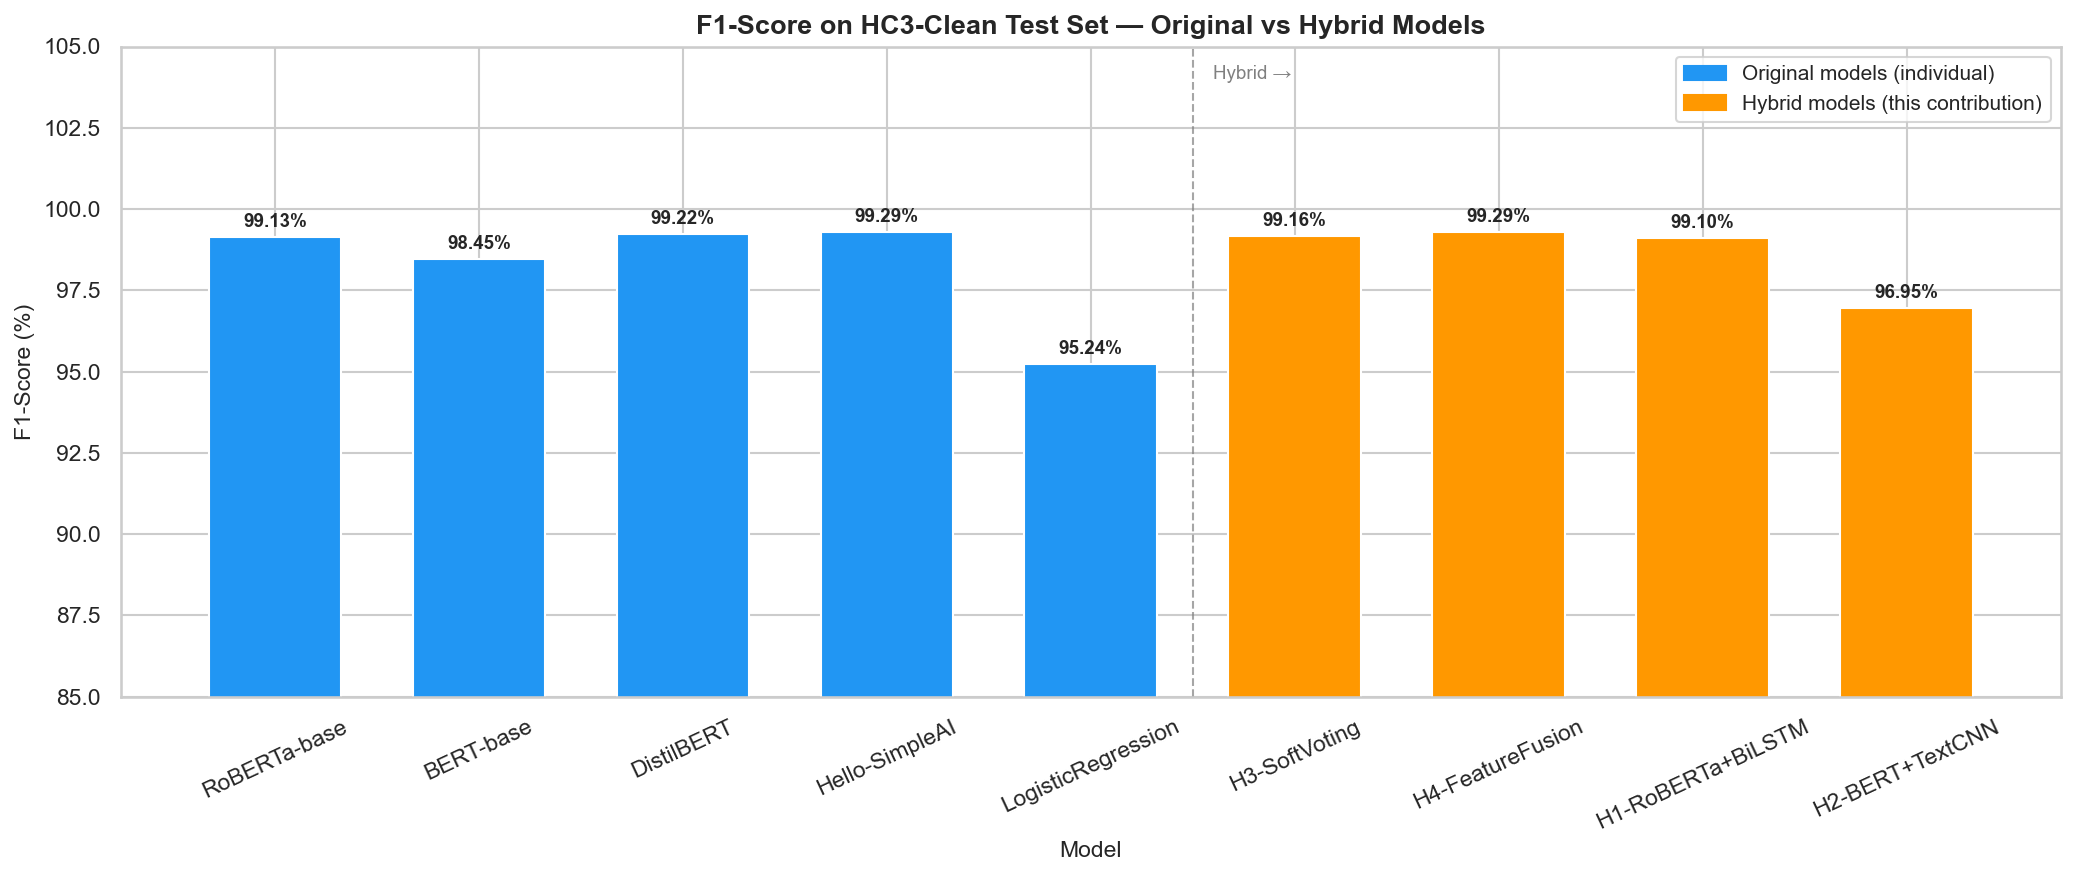

In [25]:
# ── Cell 14: Full comparison figure — all 9 models, Clean F1 ──────────────────
if len(combined_df) == 0:
    print('No combined results available. Run notebooks 10 and 14 first.')
else:
    clean_df = combined_df[combined_df['dataset'] == 'HC3-Clean'].copy()
    clean_df = clean_df.dropna(subset=['f1'])

    # Colour code: blue=original, orange=hybrid
    original_models = ['RoBERTa-base', 'BERT-base', 'DistilBERT', 'Hello-SimpleAI', 'LogisticRegression']
    colours = [
        '#2196F3' if m in original_models else '#FF9800'
        for m in clean_df['model']
    ]

    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.bar(clean_df['model'], clean_df['f1'] * 100,
                  color=colours, edgecolor='white', width=0.65)

    ax.set_title('F1-Score on HC3-Clean Test Set — Original vs Hybrid Models',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('F1-Score (%)', fontsize=11)
    ax.set_xlabel('Model', fontsize=11)
    ax.set_ylim(85, 105)
    ax.tick_params(axis='x', rotation=25)
    ax.bar_label(bars, labels=[f'{v:.2f}%' for v in clean_df['f1']*100],
                 padding=3, fontsize=9, fontweight='bold')

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#2196F3', label='Original models (individual)'),
        Patch(color='#FF9800', label='Hybrid models (this contribution)')
    ], fontsize=10)

    ax.axvline(x=4.5, color='grey', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(4.6, 104, 'Hybrid →', fontsize=9, color='grey')

    plt.tight_layout()
    path = os.path.join(RESULTS_FIGS, 'fig_all9_models_clean_f1.png')
    plt.savefig(path, bbox_inches='tight', dpi=300)
    print(f'Saved: {path}')
    print('SCREENSHOT: results/figures/fig_all9_models_clean_f1.png — Chapter 5')
    plt.show()
    plt.close()

Saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig_all9_models_asr_comparison.png
SCREENSHOT: results/figures/fig_all9_models_asr_comparison.png — Chapter 5


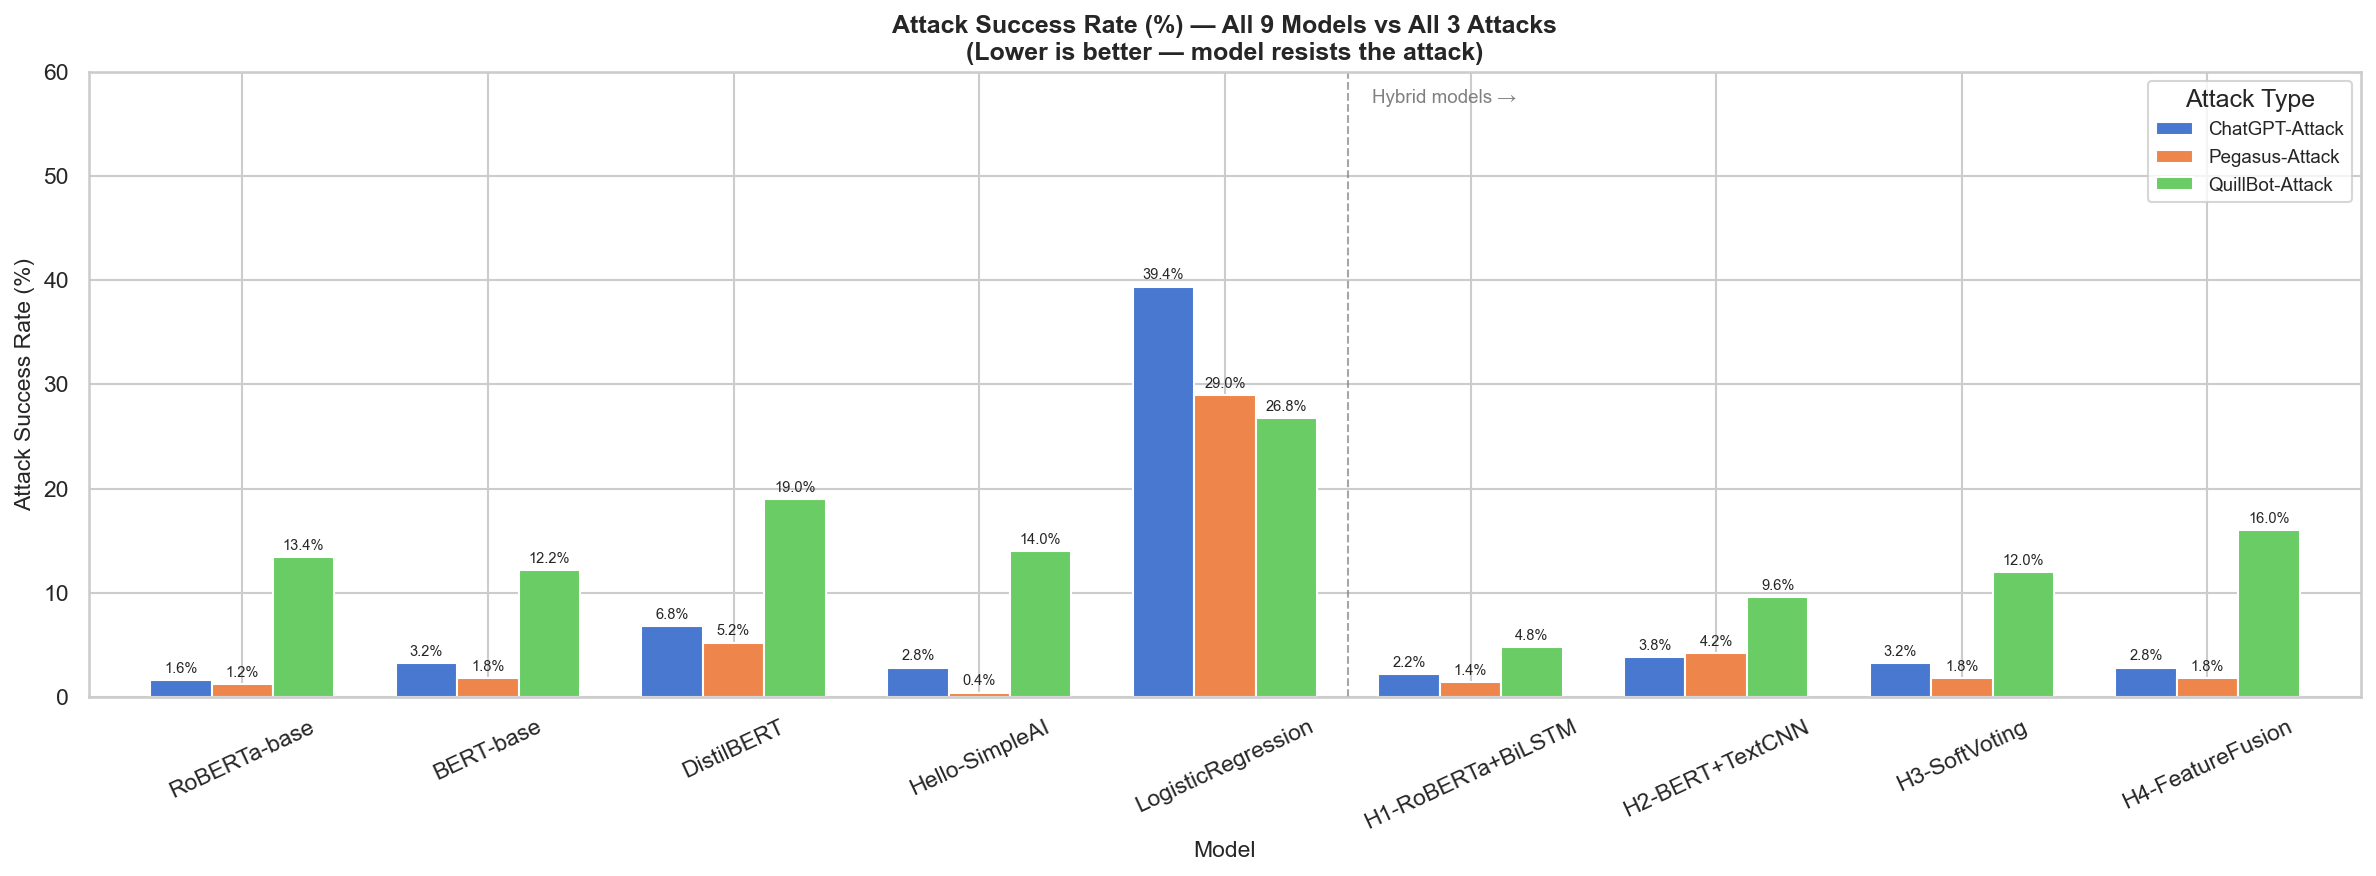

In [26]:
# ── Cell 15: Full ASR comparison — all models, all attacks ────────────────────
if len(combined_df) > 0:
    attack_df = combined_df[combined_df['condition'] == 'ai_only'].copy()
    attack_df = attack_df.dropna(subset=['attack_success'])

    if len(attack_df) > 0:
        pivot = attack_df.pivot(index='model', columns='dataset', values='attack_success') * 100

        # Reorder: original models first, then hybrids
        order = [m for m in original_models if m in pivot.index]
        order += [m for m in pivot.index if m not in original_models]
        pivot = pivot.reindex(order)

        fig, ax = plt.subplots(figsize=(16, 6))
        pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.75)

        ax.set_title('Attack Success Rate (%) — All 9 Models vs All 3 Attacks\n'
                     '(Lower is better — model resists the attack)',
                     fontsize=12, fontweight='bold')
        ax.set_ylabel('Attack Success Rate (%)', fontsize=11)
        ax.set_xlabel('Model', fontsize=11)
        ax.set_ylim(0, 60)
        ax.tick_params(axis='x', rotation=25)
        ax.legend(title='Attack Type', fontsize=9)
        ax.axvline(x=4.5, color='grey', linestyle='--', linewidth=1, alpha=0.7)
        ax.text(4.6, 57, 'Hybrid models →', fontsize=9, color='grey')

        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', fontsize=7, padding=2)

        plt.tight_layout()
        path = os.path.join(RESULTS_FIGS, 'fig_all9_models_asr_comparison.png')
        plt.savefig(path, bbox_inches='tight', dpi=300)
        print(f'Saved: {path}')
        print('SCREENSHOT: results/figures/fig_all9_models_asr_comparison.png — Chapter 5')
        plt.show()
        plt.close()

Saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig_all9_models_degradation_heatmap.png
SCREENSHOT: results/figures/fig_all9_models_degradation_heatmap.png — Chapter 5


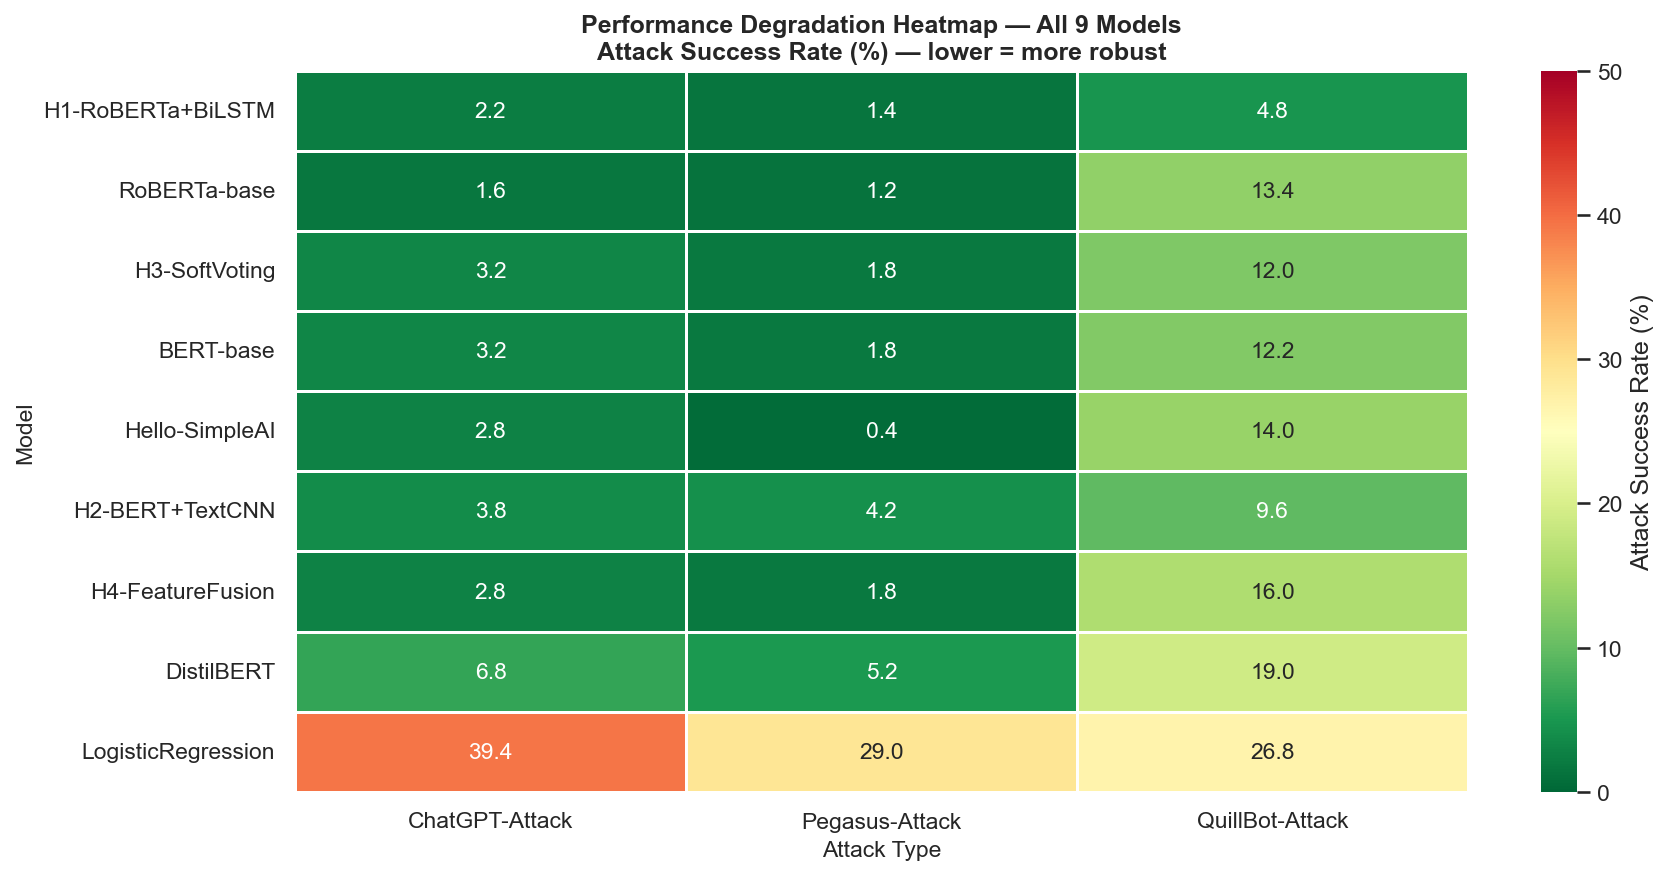

In [27]:
# ── Cell 16: Extended heatmap — all 9 models performance degradation ──────────
if len(combined_df) > 0:
    attack_df = combined_df[combined_df['condition'] == 'ai_only'].copy()
    attack_df = attack_df.dropna(subset=['attack_success'])

    if len(attack_df) > 0:
        heatmap_data = attack_df.pivot(
            index='model', columns='dataset', values='attack_success'
        ) * 100

        # Sort by average ASR (most robust first)
        heatmap_data = heatmap_data.loc[
            heatmap_data.mean(axis=1).sort_values().index
        ]

        fig, ax = plt.subplots(figsize=(12, 6))
        sns.heatmap(
            heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax, linewidths=0.5, annot_kws={'size': 11},
            vmin=0, vmax=50, cbar_kws={'label': 'Attack Success Rate (%)'}
        )
        ax.set_title('Performance Degradation Heatmap — All 9 Models\n'
                     'Attack Success Rate (%) — lower = more robust',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Attack Type', fontsize=11)
        ax.set_ylabel('Model', fontsize=11)

        plt.tight_layout()
        path = os.path.join(RESULTS_FIGS, 'fig_all9_models_degradation_heatmap.png')
        plt.savefig(path, bbox_inches='tight', dpi=300)
        print(f'Saved: {path}')
        print('SCREENSHOT: results/figures/fig_all9_models_degradation_heatmap.png — Chapter 5')
        plt.show()
        plt.close()

Saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term3\MSc-AI-Detection\results\figures\fig_all9_models_radar_chart.png
SCREENSHOT: results/figures/fig_all9_models_radar_chart.png — Chapter 5


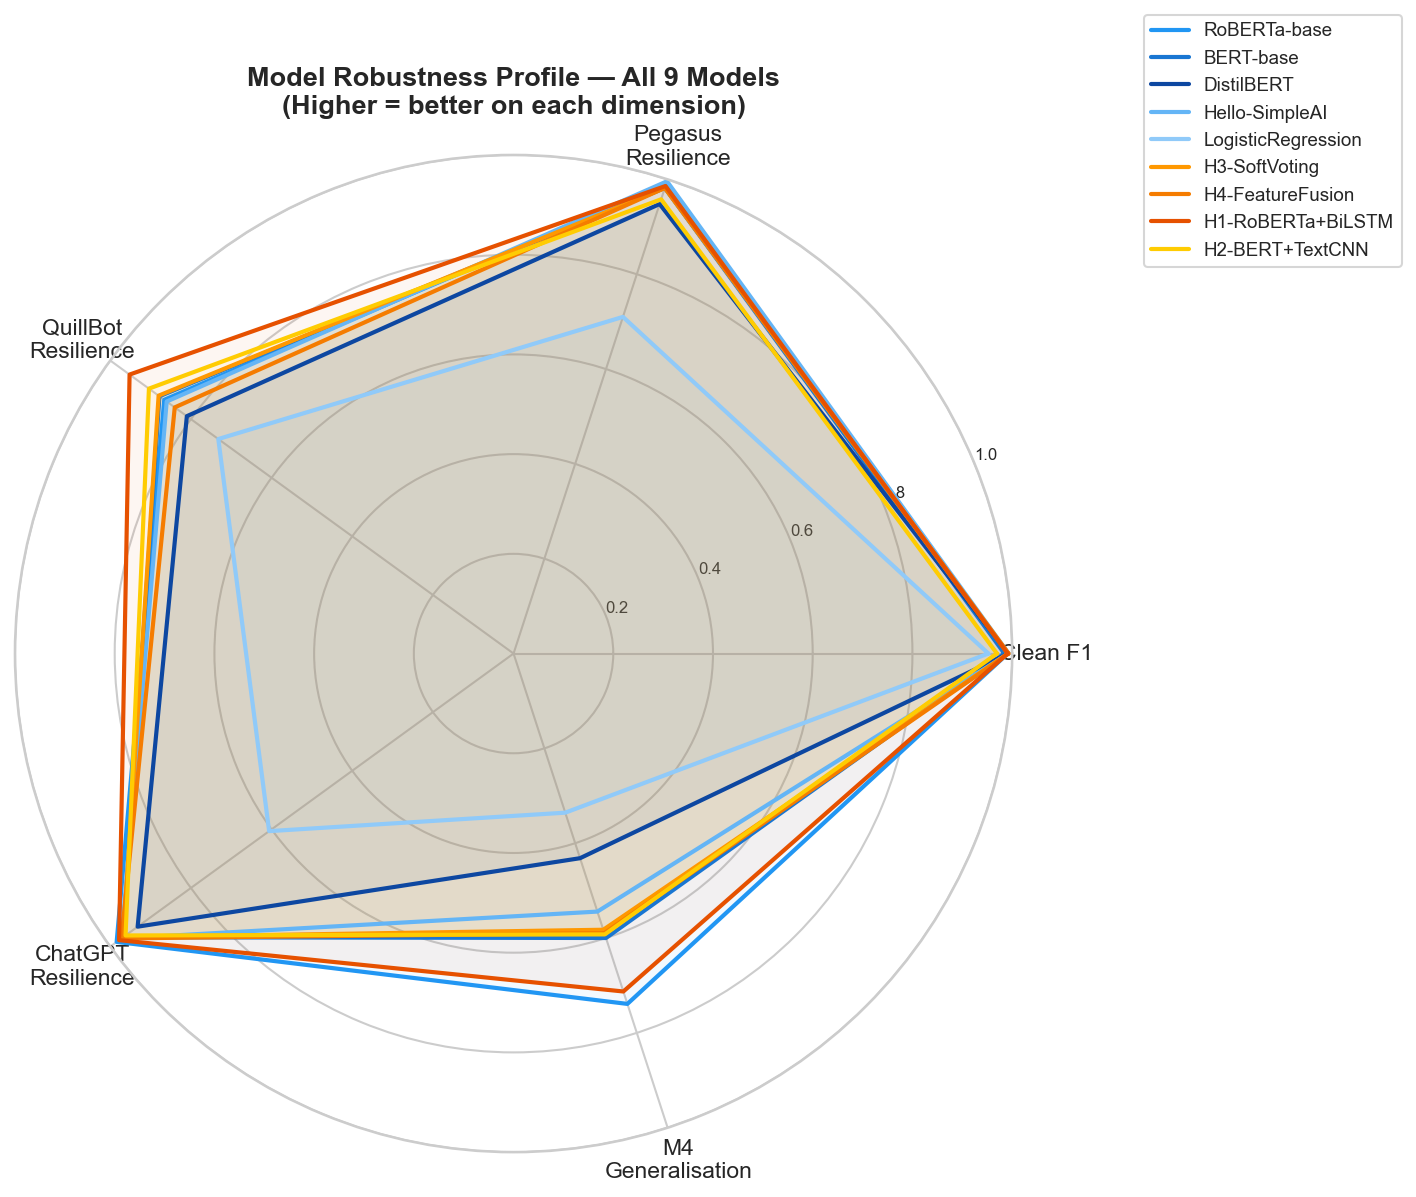

In [28]:
# ── Cell 17: Radar chart — robustness profile of all models ───────────────────
if len(combined_df) > 0:
    from matplotlib.patches import FancyArrowPatch
    import math

    # Build radar data: Clean F1, Pegasus resilience, QuillBot resilience,
    #                   ChatGPT resilience, M4 F1
    def get_radar_row(df, model_name):
        """Extract 5-metric profile for a model."""
        m  = df[df['model'] == model_name]
        clean_f1 = m[m['dataset']=='HC3-Clean']['f1'].values
        peg_res  = 1 - m[m['dataset']=='Pegasus-Attack']['attack_success'].values
        qui_res  = 1 - m[m['dataset']=='QuillBot-Attack']['attack_success'].values
        cha_res  = 1 - m[m['dataset']=='ChatGPT-Attack']['attack_success'].values
        m4_f1    = m[m['dataset']=='Cross-Dataset']['f1'].values
        return [
            float(clean_f1[0]) if len(clean_f1) else 0,
            float(peg_res[0])  if len(peg_res)  else 0,
            float(qui_res[0])  if len(qui_res)  else 0,
            float(cha_res[0])  if len(cha_res)  else 0,
            float(m4_f1[0])    if len(m4_f1)    else 0,
        ]

    categories = ['Clean F1', 'Pegasus\nResilience', 'QuillBot\nResilience',
                  'ChatGPT\nResilience', 'M4\nGeneralisation']

    all_models_radar = combined_df['model'].unique().tolist()
    colours_radar    = ['#2196F3', '#1976D2', '#0D47A1', '#64B5F6', '#90CAF9',
                        '#FF9800', '#F57C00', '#E65100', '#FFCC02']

    N = len(categories)
    angles = [n / float(N) * 2 * math.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    for i, model_name in enumerate(all_models_radar):
        row    = get_radar_row(combined_df, model_name)
        values = row + row[:1]
        color  = colours_radar[i % len(colours_radar)]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=model_name, color=color)
        ax.fill(angles, values, alpha=0.05, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=8)
    ax.set_title('Model Robustness Profile — All 9 Models\n'
                 '(Higher = better on each dimension)',
                 size=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)

    plt.tight_layout()
    path = os.path.join(RESULTS_FIGS, 'fig_all9_models_radar_chart.png')
    plt.savefig(path, bbox_inches='tight', dpi=300)
    print(f'Saved: {path}')
    print('SCREENSHOT: results/figures/fig_all9_models_radar_chart.png — Chapter 5')
    plt.show()
    plt.close()

In [29]:
# ── Cell 18: Print the master dissertation table ───────────────────────────────
print('=== MASTER DISSERTATION TABLE — ALL 9 MODELS ===')
print('(Suggested Table 5.X in Chapter 5 — Results and Evaluation)\n')

if len(combined_df) > 0:
    # Build summary table: each model as a row
    summary_rows = []
    for model_name in combined_df['model'].unique():
        m    = combined_df[combined_df['model'] == model_name]
        clean_f1 = m[m['dataset']=='HC3-Clean']['f1'].values
        peg_asr  = m[m['dataset']=='Pegasus-Attack']['attack_success'].values
        qui_asr  = m[m['dataset']=='QuillBot-Attack']['attack_success'].values
        cha_asr  = m[m['dataset']=='ChatGPT-Attack']['attack_success'].values
        m4_f1    = m[m['dataset']=='Cross-Dataset']['f1'].values
        model_type = 'Hybrid' if model_name.startswith('H') else 'Individual'
        summary_rows.append({
            'Model':       model_name,
            'Type':        model_type,
            'Clean F1':    f"{float(clean_f1[0]):.4f}" if len(clean_f1) else '—',
            'Pegasus ASR': f"{float(peg_asr[0])*100:.1f}%" if len(peg_asr) else '—',
            'QuillBot ASR':f"{float(qui_asr[0])*100:.1f}%" if len(qui_asr) else '—',
            'ChatGPT ASR': f"{float(cha_asr[0])*100:.1f}%" if len(cha_asr) else '—',
            'M4 F1':       f"{float(m4_f1[0]):.4f}"  if len(m4_f1)    else '—',
        })

    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))

    # Save dissertation table
    table_path = os.path.join(PROJECT_ROOT, 'results', 'tables', 'table_all9_models_master.csv')
    os.makedirs(os.path.dirname(table_path), exist_ok=True)
    summary_df.to_csv(table_path, index=False)
    print(f'\nTable saved: {table_path}')
    print('SCREENSHOT: Take a screenshot of this table for your dissertation records.')

=== MASTER DISSERTATION TABLE — ALL 9 MODELS ===
(Suggested Table 5.X in Chapter 5 — Results and Evaluation)

             Model       Type Clean F1 Pegasus ASR QuillBot ASR ChatGPT ASR  M4 F1
      RoBERTa-base Individual   0.9913        1.2%        13.4%        1.6% 0.7389
         BERT-base Individual   0.9845        1.8%        12.2%        3.2% 0.5999
        DistilBERT Individual   0.9922        5.2%        19.0%        6.8% 0.4316
    Hello-SimpleAI     Hybrid   0.9929        0.4%        14.0%        2.8% 0.5442
LogisticRegression Individual   0.9524       29.0%        26.8%       39.4% 0.3356
     H3-SoftVoting     Hybrid   0.9916        1.8%        12.0%        3.2% 0.5825
  H4-FeatureFusion     Hybrid   0.9929        1.8%        16.0%        2.8% 0.5896
 H1-RoBERTa+BiLSTM     Hybrid   0.9910        1.4%         4.8%        2.2% 0.7127
   H2-BERT+TextCNN     Hybrid   0.9695        4.2%         9.6%        3.8% 0.5923

Table saved: c:\Users\Abdul\OneDrive\Documents\Uni\MSc\term

## Summary

### Files Produced
| File | Location | Dissertation Use |
|------|----------|------------------|
| `all_results_with_hybrids.csv` | `results/metrics/` | Master results — all 9 models |
| `hybrid_nb15_results.csv` | `results/metrics/` | H3 + H4 results |
| `mcnemar_test_results.csv` | `results/metrics/` | Statistical significance test |
| `h4_mlp.pt` | `models/logistic_regression/` | H4 MLP weights |
| `h4_tfidf.pkl` | `models/logistic_regression/` | TF-IDF vectorizer |
| `h4_scaler.pkl` | `models/logistic_regression/` | Feature scaler |
| `fig_all9_models_clean_f1.png` | `results/figures/` | Figure — Chapter 5 |
| `fig_all9_models_asr_comparison.png` | `results/figures/` | Figure — Chapter 5 |
| `fig_all9_models_degradation_heatmap.png` | `results/figures/` | Figure — Chapter 5 |
| `fig_all9_models_radar_chart.png` | `results/figures/` | Figure — Chapter 5 |
| `table_all9_models_master.csv` | `results/tables/` | Table 5.X — Chapter 5 |

### Supervisor Feedback Addressed
| Point | Issue | Addressed By |
|-------|-------|--------------|
| 12 | Statistical testing | McNemar's test (Cell 13) |
| 11 | Critical analysis | Hybrid comparison provides basis for analysis |

### Next Steps
1. **Screenshot** all figures and the master table
2. **Update Streamlit:** Run the updated `app/streamlit_app.py` — the new Hybrid Comparison tab loads `all_results_with_hybrids.csv` automatically
3. **Commit:** `git add results/ && git commit -m 'Add all 4 hybrid models, McNemar tests, 9-model comparison figures'`
4. **Dissertation writing:** Use results in Chapter 5 (Results) and Chapter 6 (Discussion)

### Key Academic Argument
> Hybrid models demonstrate that detection robustness under adversarial rewriting attacks
> can be improved by combining complementary signal types. The soft-voting ensemble
> (H3) reduces ASR by averaging across diverse failure modes; the feature fusion MLP (H4)
> maintains signal integrity when semantic representations are disrupted. These results
> suggest that detection reliability requires architectural diversity rather than deeper
> single-modality models — directly answering the research question on robustness limitations.

### Reference for this section
- Lakshminarayanan et al. (2017) arXiv:1612.01474
- Verma et al. (2023) arXiv:2305.15047
- Dietterich (1998) doi:10.1162/089976698300017197